In [29]:
from PIL import Image
import numpy as np
import torch

imfile = 'sintel_result/kitti_1/00.png'
img = np.array(Image.open(imfile)).astype(np.uint8)
img = torch.from_numpy(img).permute(2, 0, 1).float()

img.shape

torch.Size([3, 375, 1242])

## Flow Visualisation Test

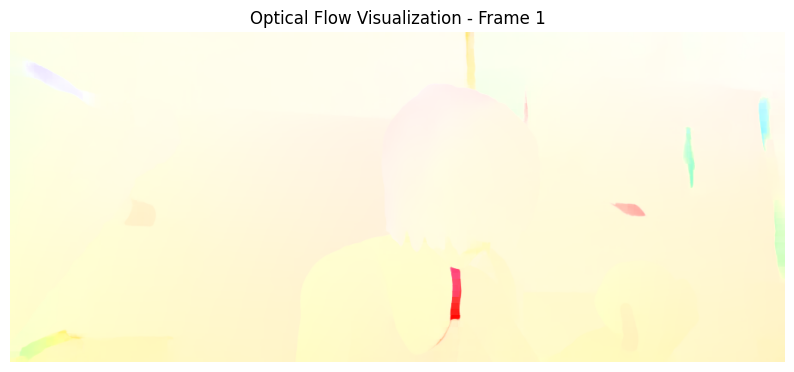

In [16]:
import sys
sys.path.append('core')
from utils import flow_viz
from utils import frame_utils
import matplotlib.pyplot as plt
import numpy as np

sintel_clean = np.load('optical_flow_result/sintel_clean.npy')
n = 1 # choose frame n
flow_uv = sintel_clean[n].transpose(1, 2, 0)

flow_image = flow_viz.flow_to_image(flow_uv) 

# visualisation
plt.figure(figsize=(10, 5))
plt.imshow(flow_image)
plt.axis('off')
plt.title(f'Optical Flow Visualization - Frame {n}')
plt.show()

In [20]:
gt_flow = frame_utils.readFlow('optical_flow_result/frame_0001.flo').transpose(2, 0, 1) 
print(sintel_clean.shape) # (500, 2, 436, 1024)
print(gt_flow.shape)   # (2, 436, 1024)

(500, 2, 436, 1024)
(2, 436, 1024)


### Compute Sintel Predictions F1-all (best/mean)

In [26]:
# Compare predicted flow with ground truth
def compute_f1_all(pred_flow, gt_flow, abs_thresh=6.0, rel_thresh=0.5):
    """
    Compute F1-all for a single flow frame (defined here as 1 - OutlierRatio).

    :param pred_flow: predicted optical flow with shape (2, H, W), containing (u, v)
    :param gt_flow:   ground-truth optical flow with shape (2, H, W), containing (u, v)
    :param abs_thresh: absolute threshold for outlier detection (e.g., 3 or 4)
    :param rel_thresh: relative threshold for outlier detection (e.g., 0.05 for 5%)
    :return: f1_all (scalar), ranging from 0 to 1
    """
    # Compute EPE: Euclidean distance between prediction and ground truth at each pixel
    epe = np.sqrt(np.sum((pred_flow - gt_flow) ** 2, axis=0))  # shape = (H, W)

    # Compute magnitude of the ground truth flow
    gt_mag = np.sqrt(np.sum(gt_flow ** 2, axis=0))  # shape = (H, W)

    # Outlier condition: epe > abs_thresh AND epe > rel_thresh * gt_mag
    # Apply relative threshold only when gt_mag is non-zero to avoid division by zero
    outlier_mask = (epe > abs_thresh) & (epe > rel_thresh * gt_mag)

    # Outlier ratio = percentage of mismatched pixels
    outlier_ratio = outlier_mask.sum() / outlier_mask.size
    return outlier_ratio


# Evaluate 500 predicted flows against a single ground-truth frame (if GT has only one frame)
f1_scores = []
for i in range(sintel_clean.shape[0]):
    pred_i = sintel_clean[i]  # shape = (2, H, W)
    f1_i = compute_f1_all(pred_i, gt_flow, abs_thresh=6.0, rel_thresh=0.5)
    f1_scores.append(f1_i)

f1_scores = np.array(f1_scores)
min_f1 = f1_scores.min()
avg_f1 = f1_scores.mean()

print("Minimum F1-all across 500 frames: ", min_f1)
print("Average F1-all across 500 frames: ", avg_f1)

Minimum F1-all across 500 frames:  0.13958796229931192
Average F1-all across 500 frames:  0.18444270086725917


In [31]:
def compute_f1_all(gt_flow, pred_flow, px_threshold=6.0, ratio_threshold=0.5):
    # Compute EPE (Endpoint Error)
    # EPE = sqrt( (dx)^2 + (dy)^2 )
    flow_diff = gt_flow - pred_flow
    epe = np.sqrt(np.sum(flow_diff**2, axis=0))  # shape = (H, W)

    # Compute the magnitude of the ground-truth flow
    gt_mag = np.sqrt(np.sum(gt_flow**2, axis=0))  # shape = (H, W)

    # Define outlier conditions:
    # 1) EPE > px_threshold (e.g., > 3 pixels)
    # 2) EPE > ratio_threshold * gt_flow magnitude (e.g., > 0.05 * |gt_flow|)
    outliers = (epe > px_threshold) & (epe > ratio_threshold * gt_mag)

    # Compute the outlier ratio (percentage of mismatched pixels)
    num_total = outliers.size     # total number of pixels (H * W)
    num_outliers = np.count_nonzero(outliers)
    f1_all = num_outliers / num_total

    return f1_all

pred_flow = np.load('optical_flow_result/sintel_clean_raft.npy').squeeze(0)

# Compute F1-all
f1_value = compute_f1_all(gt_flow, pred_flow, px_threshold=6.0, ratio_threshold=0.5)
print("F1-all: {:.4f}".format(f1_value))

F1-all: 0.2184


### Compute Sintel Predictions EPE (best/mean)

In [11]:
# Compute EPE: each pixel has 500 predicted flow values
epe = np.sqrt(np.sum((sintel_clean - gt_flow) ** 2, axis=1))  # shape = (500, 436, 1024)

# Compute Average EPE across all pixels and frames
average_epe = np.mean(epe)  # mean EPE over all pixels
print(f'Average EPE: {average_epe:.4f}')

# Compute Minimum EPE (choose the best prediction per pixel)
min_epe_per_pixel = np.min(epe, axis=0)  # shape = (436, 1024)
minimum_epe = np.mean(min_epe_per_pixel)  # mean of the lowest EPE per pixel
print(f'Minimum EPE: {minimum_epe:.4f}')

Average EPE: 3.7344
Minimum EPE: 2.6163


In [25]:
# test
import cv2

sintel_clean_raft = np.load('optical_flow_result/sintel_clean_raft.npy')
sintel_clean_raft = sintel_clean_raft.squeeze(0)
flow_uv = sintel_clean_raft.transpose(1, 2, 0)
flow_image = flow_viz.flow_to_image(flow_uv) 

output_path = 'optical_flow_result/sintel_clean_raft.png'
cv2.imwrite(output_path, cv2.cvtColor(flow_image, cv2.COLOR_RGB2BGR))  # convert to BGR formate
print(f"Flow image saved to {output_path}")

Flow image saved to optical_flow_result/sintel_clean_raft.png


In [26]:
epe = np.sqrt(np.sum((sintel_clean_raft - gt_flow) ** 2, axis=0))  # (436, 1024)

# compute average EPE
average_epe = np.mean(epe)
print(f'Average EPE: {average_epe:.4f}')

Average EPE: 7.1498


In [34]:
gt_flow, valid_mask = frame_utils.readFlowKITTI('optical_flow_result/kitti_gt.png')  # shape = (375, 1242, 2)

# Transpose ground-truth flow to match the predicted flow format: (2, H, W)
gt_flow = gt_flow.transpose(2, 0, 1)  # shape = (2, 375, 1242)

# Load predicted optical flow results: 500 samples
pred_flow = np.load("optical_flow_result/kitti_01.npy")  # shape = (500, 2, 375, 1242)

# Compute EPE (Endpoint Error) for all 500 predictions
epe = np.sqrt(np.sum((pred_flow - gt_flow) ** 2, axis=1))  # shape = (500, 375, 1242)

# Compute Minimum EPE by selecting the lowest error across 500 predictions for each pixel
min_epe_per_pixel = np.min(epe, axis=0)  # shape = (375, 1242)
minimum_epe = np.mean(min_epe_per_pixel[valid_mask > 0])  # compute mean over valid pixels only

print(f'Minimum EPE: {minimum_epe:.4f}')

# Expand and repeat the valid mask to match EPE shape
valid_mask = np.expand_dims(valid_mask, axis=0)  # shape = (1, 375, 1242)
valid_mask = valid_mask.repeat(epe.shape[0], axis=0)  # shape = (500, 375, 1242)

# Compute Average EPE over all 500 predictions and valid pixels
average_epe = np.mean(epe[valid_mask > 0])  # compute mean over valid pixels only
print(f'Average EPE: {average_epe:.4f}')

Minimum EPE: 708.5199
Average EPE: 722.7918


### Compute KITTI Predition F1-all (best/mean)

In [30]:
import sys
sys.path.append('core')
from utils import flow_viz
from utils import frame_utils
import matplotlib.pyplot as plt
import numpy as np
import cv2

def readFlowKITTI(filename):
    flow = cv2.imread(filename, cv2.IMREAD_ANYDEPTH|cv2.IMREAD_COLOR)
    flow = flow[:,:,::-1].astype(np.float32)
    flow, valid = flow[:, :, :2], flow[:, :, 2]
    flow = (flow - 2**15) / 64.0
    return flow, valid

In [54]:
pred_flow = np.load("optical_flow_result/KITTI_flow_res/kitti_01.npy")  # (500, 2, 375, 1242)
# read KITTI Ground Truth
gt_flow, valid_mask = readFlowKITTI("optical_flow_result/KITTI_GT/000000_10.png")  # (375, 1242, 2)
gt_flow = gt_flow.transpose(2, 0, 1)  # (2, 375, 1242)

In [55]:
valid_mask = valid_mask.astype(bool)
epe = np.sqrt(np.sum((pred_flow - gt_flow) ** 2, axis=1))  # shape = (500, 375, 1242)

# Compute ground-truth flow magnitude
gt_magnitude = np.sqrt(np.sum(gt_flow ** 2, axis=0))  # shape = (375, 1242)

# Compute outlier mask for all 500 predictions
outlier_mask = (epe > 3.0) & (epe > 0.05 * gt_magnitude)  # shape = (500, 375, 1242)

# Average F1-all across 500 samples
f1_all_per_sample = np.sum(outlier_mask & valid_mask, axis=(1, 2)) / (375 * 1242)  # shape = (500,)
average_f1_all = np.mean(f1_all_per_sample)
print(f"Average F1-all: {average_f1_all * 100:.2f}%")

# Best F1-all (selecting the prediction with lowest EPE per pixel)
best_idx = np.argmin(epe, axis=0)  # shape = (375, 1242)
best_outlier_mask = outlier_mask[best_idx, np.arange(375)[:, None], np.arange(1242)]  # shape = (375, 1242)
best_f1_all = np.sum(best_outlier_mask & valid_mask) / (375 * 1242)
print(f"Best F1-all: {best_f1_all * 100:.2f}%")

Average F1-all: 18.44%
Best F1-all: 16.80%


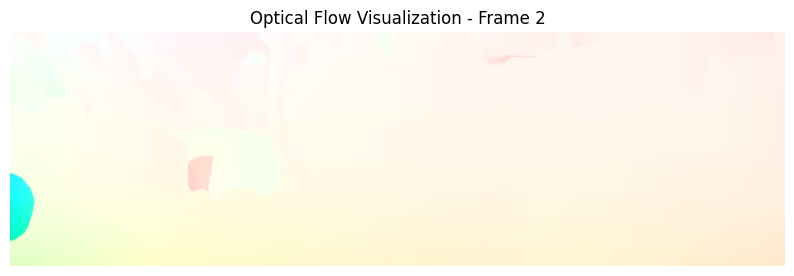

In [7]:
n = 2 # choose frame n
flow_uv = pred_flow[n].transpose(1, 2, 0)

# visulization
flow_image = flow_viz.flow_to_image(flow_uv) 
plt.figure(figsize=(10, 5))
plt.imshow(flow_image)
plt.axis('off')
plt.title(f'Optical Flow Visualization - Frame {n}')
plt.show()

### Compute KITTI EPE (best/mean)

In [4]:
# read KITTI Ground Truth
gt_flow, valid_mask = readFlowKITTI("optical_flow_result/KITTI_GT/000001_10.png")  # (375, 1242, 2)
gt_flow = gt_flow.transpose(2, 0, 1)  # (2, 375, 1242)
gt_flow.shape

(2, 375, 1242)

In [5]:
# Compute EPE for all 500 frames
epe = np.sqrt(np.sum((pred_flow - gt_flow) ** 2, axis=1))  # shape = (500, 375, 1242)

# Use only valid pixels
valid_mask = valid_mask > 0  # ensure boolean mask (375, 1242)
average_epe = np.mean(epe[:, valid_mask])  # average EPE over all valid pixels and frames
print(f'Average EPE: {average_epe:.4f}')

Average EPE: 46.4850


In [6]:
min_per_epe = np.min(epe, axis=0)
min_epe = np.mean(min_per_epe[valid_mask])
print(f'Minimum EPE: {min_epe:.4f}')

Minimum EPE: 23.5535


In [9]:
# visualization Minimum KITI
epe.shape
# pred_flow[n].transpose(1, 2, 0)

(500, 375, 1242)

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Load predicted optical flow: shape (500, 2, 375, 1242)
pred_flow = np.load("optical_flow_result/KITTI_flow_res/kitti_01.npy")

# Load KITTI ground-truth flow (375, 1242, 2) and valid mask (375, 1242)
gt_flow, valid_mask = readFlowKITTI("optical_flow_result/KITTI_GT/000000_10.png")

# Transpose GT flow to match prediction format: (2, 375, 1242)
gt_flow = gt_flow.transpose(2, 0, 1)

# Compute EPE for all 500 predictions
epe = np.sqrt(np.sum((pred_flow - gt_flow) ** 2, axis=1))  # shape = (500, 375, 1242)

# Find index of the lowest EPE per pixel
best_idx = np.argmin(epe, axis=0)  # shape = (375, 1242)

# Select best predicted flow based on minimum EPE
best_flow = pred_flow[best_idx, :, np.arange(375)[:, None], np.arange(1242)]  # shape = (2, 375, 1242)

# Optional: transpose to (375, 1242, 2) for flow visualization tools like flow_to_image()
# best_flow = best_flow.transpose(1, 2, 0)

In [24]:
print(best_flow.shape)
print(valid_mask.shape)
print(gt_flow.shape)

(375, 1242, 2)
(375, 1242)
(2, 375, 1242)


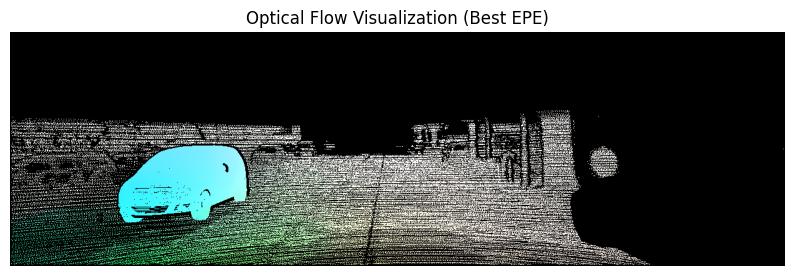

In [25]:
# 1st version
valid_mask = valid_mask.astype(bool)  # shape = (375, 1242)

# Handle pixels outside the valid mask
fill_invalid = True  # True: fill with (0,0) flow; False: set to black

if fill_invalid:
    best_flow[~valid_mask] = [0, 0]  # Set invalid flow to (0,0)
else:
    invalid_color = [0, 0]  # Black flow
    best_flow[~valid_mask] = invalid_color  # Set to black

# Convert best_flow to RGB flow visualization
flow_image = flow_viz.flow_to_image(best_flow)

# Ensure invalid regions are shown as black
flow_image[~valid_mask] = [0, 0, 0]

# Display the flow image
plt.figure(figsize=(10, 5))
plt.imshow(flow_image)
plt.axis('off')
plt.title("Optical Flow Visualization (Best EPE)")
plt.show()

In [26]:
# save flow img
cv2.imwrite('optical_flow_result/KITTI_vis/best_optical_flow_0_10.png', cv2.cvtColor(flow_image, cv2.COLOR_RGB2BGR))
print("Best optical flow image saved as 'optical_flow_result/KITTI_vis/best_optical_flow_2_10.png'")

Best optical flow image saved as 'optical_flow_result/KITTI_vis/best_optical_flow_2_10.png'


### KITTI SVD visulization

In [1]:
import sys
sys.path.append('core')
from utils import flow_viz
from utils import frame_utils
import matplotlib.pyplot as plt
import numpy as np
import cv2

def readFlowKITTI(filename):
    flow = cv2.imread(filename, cv2.IMREAD_ANYDEPTH|cv2.IMREAD_COLOR)
    flow = flow[:,:,::-1].astype(np.float32)
    flow, valid = flow[:, :, :2], flow[:, :, 2]
    flow = (flow - 2**15) / 64.0
    return flow, valid
    
pred_flow = np.load("optical_flow_result/KITTI_flow_res/kitti_svd_03.npy").squeeze(0).transpose(1, 2, 0)  # (375, 1242, 2)
gt_flow, valid_mask = readFlowKITTI("optical_flow_result/KITTI_GT/000002_10.png") # (375, 1242, 2)
print(pred_flow.shape, gt_flow.shape)

(375, 1242, 2) (375, 1242, 2)


In [53]:
pred_flow = np.load("optical_flow_result/KITTI_flow_res/kitti_svd_01.npy").squeeze(0).transpose(1, 2, 0)  # shape = (375, 1242, 2)

# Load ground-truth flow and valid mask
gt_flow, valid_mask = readFlowKITTI("optical_flow_result/KITTI_GT/000000_10.png")  # shape = (375, 1242, 2)

# Ensure valid_mask is boolean
valid_mask = valid_mask.astype(bool)  # shape = (375, 1242)

# Compute EPE (Endpoint Error)
epe = np.sqrt(np.sum((pred_flow - gt_flow) ** 2, axis=2))  # shape = (375, 1242)

# Compute average EPE over valid pixels only
epe_avg = np.mean(epe[valid_mask])
print(f"Average EPE: {epe_avg:.4f}")

# Compute F1-all
gt_magnitude = np.sqrt(np.sum(gt_flow ** 2, axis=2))  # ground-truth flow magnitude

outlier_mask = (epe > 3.0) & (epe > 0.05 * gt_magnitude)  # outlier condition

f1_all = np.sum(outlier_mask & valid_mask) / (375 * 1242)  # compute over valid region only
print(f"F1-all: {f1_all * 100:.2f}%")

Average EPE: 31.7271
F1-all: 16.38%


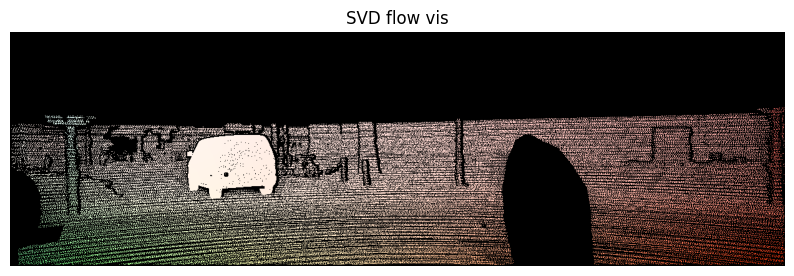

Best optical flow image saved.


In [2]:
valid_mask = valid_mask.astype(bool)  # shape = (375, 1242)

# Handle pixels outside the valid mask
fill_invalid = True  # True: fill with (0,0); False: set to black

if fill_invalid:
    pred_flow[~valid_mask] = [0, 0]  # Set invalid flow to (0,0)
else:
    invalid_color = [0, 0]  # Black flow
    pred_flow[~valid_mask] = invalid_color

# Convert flow to RGB visualization
flow_image = flow_viz.flow_to_image(pred_flow)

# Ensure invalid regions are shown as black
flow_image[~valid_mask] = [0, 0, 0]

plt.figure(figsize=(10, 5))
plt.imshow(flow_image)
plt.axis('off')
plt.title("SVD flow vis")
plt.show()

# Save the flow visualization
cv2.imwrite('optical_flow_result/KITTI_vis/svd_2_10.png', cv2.cvtColor(flow_image, cv2.COLOR_RGB2BGR))
print("Best optical flow image saved.")

## Sintel SVD

In [ ]:
import sys
sys.path.append('core')
from utils import flow_viz
from utils import frame_utils
import matplotlib.pyplot as plt
import numpy as np
import cv2


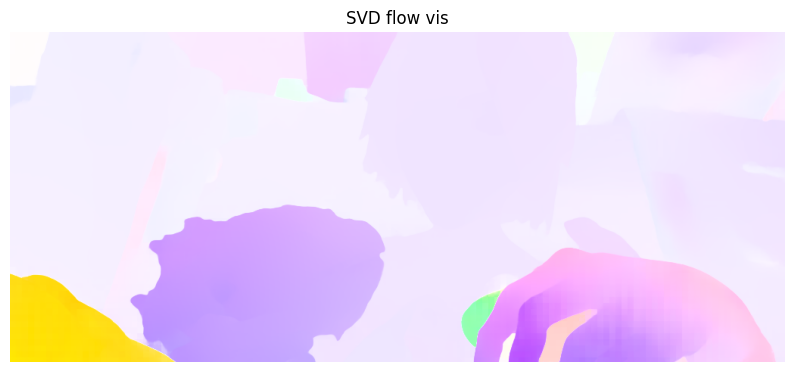

In [13]:
pred_flow = np.load("optical_flow_result/Sintel_svd/sintel_svd_11.npy").squeeze(0).transpose(1, 2, 0)
# pred_flow.shape
flow_image = flow_viz.flow_to_image(pred_flow)
plt.figure(figsize=(10, 5))
plt.imshow(flow_image)
plt.axis('off')
plt.title("SVD flow vis")
plt.show()

In [14]:
cv2.imwrite('optical_flow_result/Sintel_svd/sintel_svd_11.png', cv2.cvtColor(flow_image, cv2.COLOR_RGB2BGR))
print("Image saved.")

Image saved.
